# Proyecto 5: Spaceship Titanic - Ingesta y Exploración de Datos (EDA)

Bienvenido al año 2912. En este cuaderno realizaremos la carga y el análisis exploratorio de los datos de la nave espacial Titanic, cuyo destino fue similar al de su homónimo histórico, pero con un giro cósmico: ¡casi la mitad de los pasajeros fueron transportados a otra dimensión!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Carga de Datos

Cargamos los conjuntos de entrenamiento y prueba proporcionados en la carpeta `data/`.

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Dimensiones de Train: {train_df.shape}")
print(f"Dimensiones de Test: {test_df.shape}")
train_df.head()

Dimensiones de Train: (8693, 14)
Dimensiones de Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Análisis de Valores Nulos y Tipos de Datos

In [3]:
print("Valores nulos en Train:")
print(train_df.isnull().sum())

print("\nTipos de datos:")
print(train_df.dtypes)

Valores nulos en Train:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Tipos de datos:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


## 3. Análisis de la Variable Objetivo: `Transported`

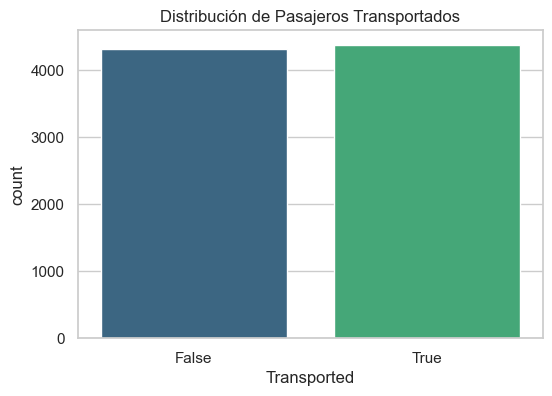

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='Transported', palette='viridis')
plt.title('Distribución de Pasajeros Transportados')
plt.show()

print(train_df['Transported'].value_counts(normalize=True))

## 4. Exploración de Variables Categóricas

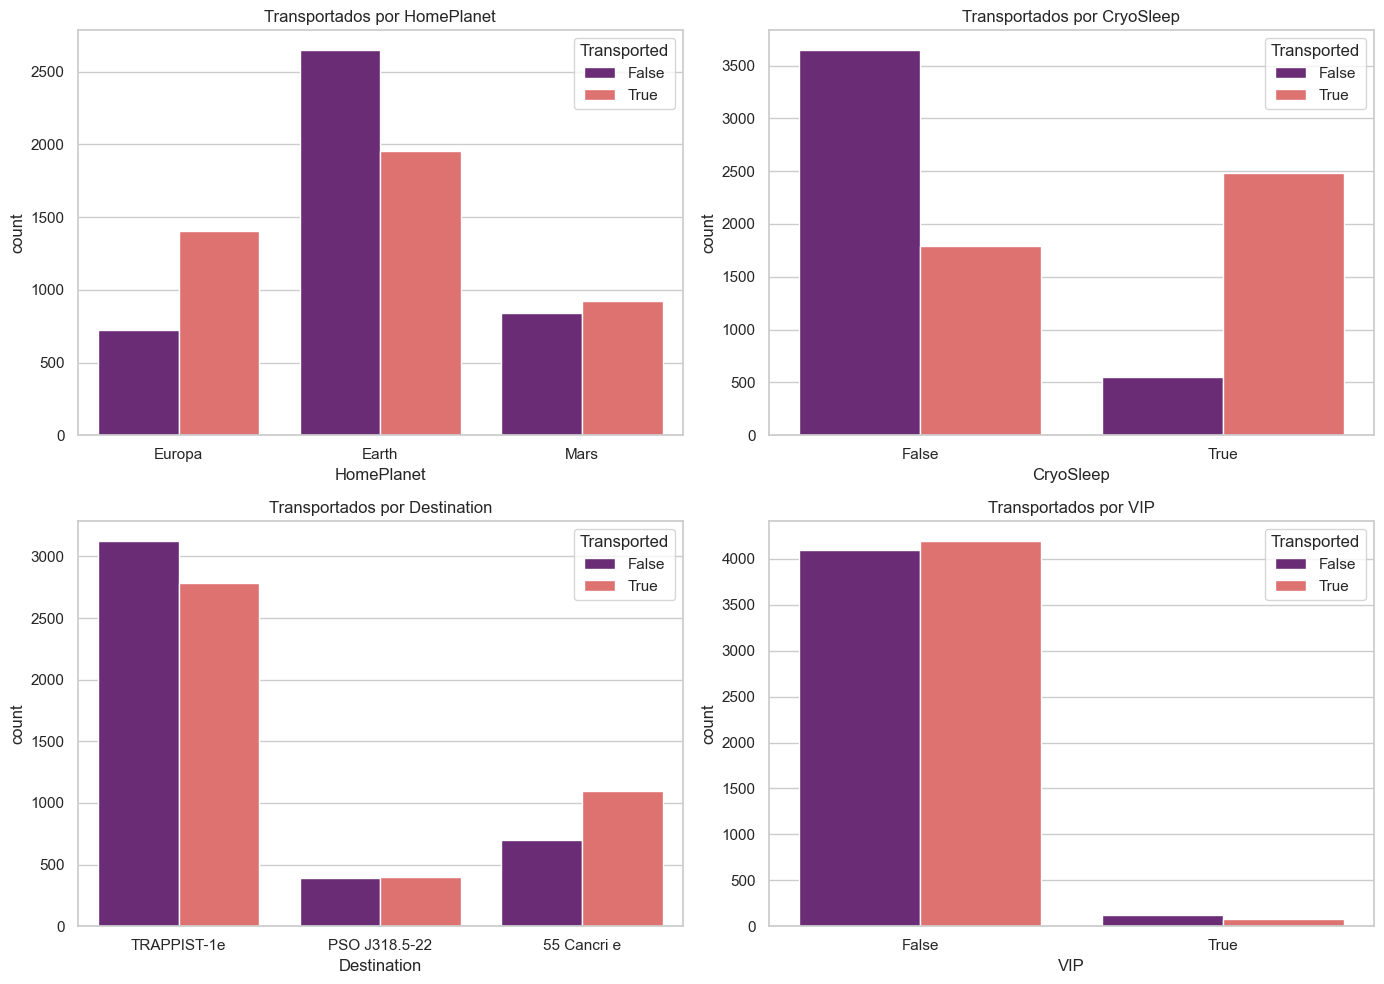

In [5]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cat_cols):
    sns.countplot(data=train_df, x=col, hue='Transported', ax=axes[i//2, i%2], palette='magma')
    axes[i//2, i%2].set_title(f'Transportados por {col}')

plt.tight_layout()
plt.show()

## 5. Exploración de Variables Numéricas

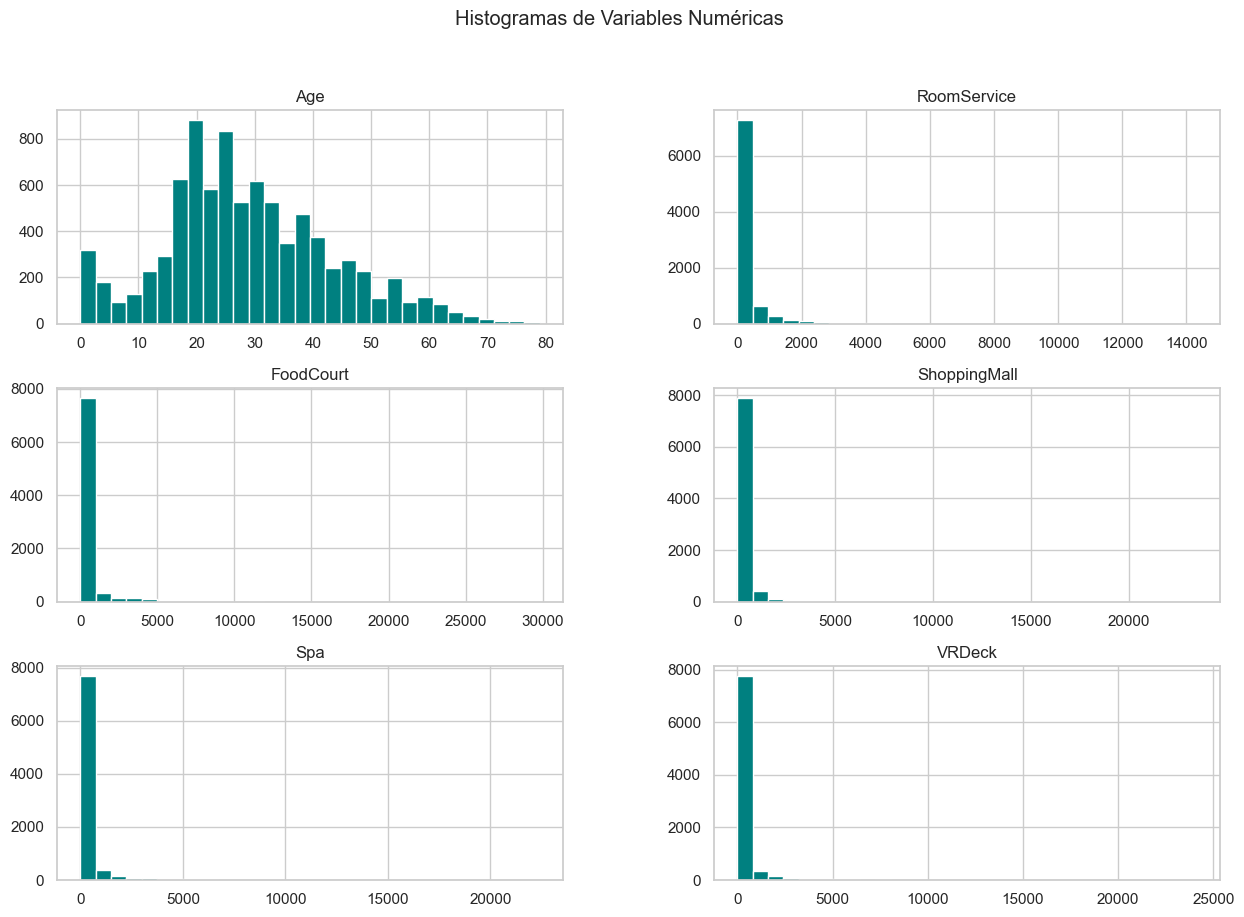

In [6]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

train_df[num_cols].hist(bins=30, figsize=(15, 10), color='teal')
plt.suptitle('Histogramas de Variables Numéricas')
plt.show()

## 6. Conclusiones del EDA

1. **Balance de Clases**: La variable objetivo está bien balanceada (aprox. 50/50).
2. **Criogenia**: Los pasajeros en criosueño tienen una probabilidad significativamente mayor de haber sido transportados.
3. **Planeta de Origen**: Europa tiene una mayor tasa de transporte comparado con Tierra o Marte.
4. **Gastos**: Las variables de gastos (`Spa`, `VRDeck`, `RoomService`) muestran distribuciones con muchos ceros y sesgadas a la derecha, indicando que muchos pasajeros no consumieron estos servicios.